In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Math
import numpy as np

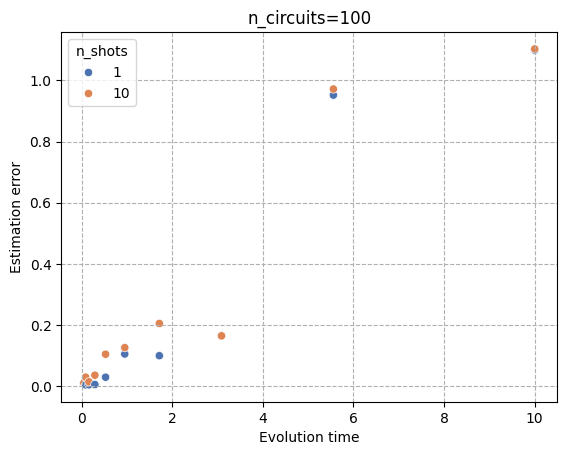

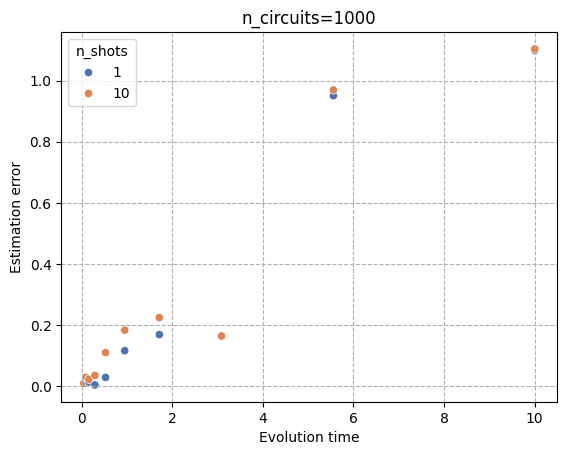

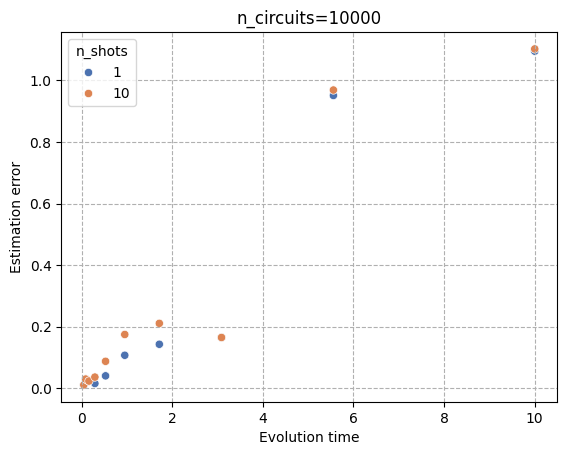

In [3]:
df = pd.read_csv("qdrift_qpe_fc_parameter_sweep_2025-09-20.csv")
times = sorted(df["time"].unique())
df = df[df["time"] > times[1] ]  # filter for specific ancilla count if needed

for groupname, groupdf in df.groupby(["n_circuits"]):
    plt.figure()
    sns.scatterplot(data=groupdf,
                    x="time",
                    y="estimation_error",
                    hue="n_shots",
                    palette="deep")
    plt.title(f"n_circuits={groupname[0]}")
    plt.xlabel("Evolution time")
    plt.ylabel("Estimation error")
    plt.grid(True, which="both", ls="--")
    plt.show()


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Math

def plot_qdrift_results(df: pd.DataFrame, loglog: bool = True) -> None:
    # -------------------------------------------------------------------------
    # Load and preprocess
    # -------------------------------------------------------------------------
    times = sorted(df["time"].unique())
    df = df[df["time"] > times[1]]  # filter out first point if needed

    n_circuits = sorted(df["n_circuits"].unique())
    n_shots = sorted(df["n_shots"].unique())

    nrows, ncols = len(n_circuits), len(n_shots)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=(4*ncols, 3.5*nrows), sharex=True, sharey=True
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes[np.newaxis, :]
    elif ncols == 1:
        axes = axes[:, np.newaxis]

    # -------------------------------------------------------------------------
    # Main plotting loop
    # -------------------------------------------------------------------------
    for i, circ in enumerate(n_circuits):
        for j, shots in enumerate(n_shots):
            ax = axes[i, j]
            subset = df[(df["n_circuits"] == circ) & (df["n_shots"] == shots)]

            if subset.empty:
                ax.set_visible(False)
                continue

            sns.scatterplot(
                data=subset, x="time", y="estimation_error",
                ax=ax, s=40, color="C0", alpha=0.7
            )

            if loglog:
                ax.set_xscale("log")
                ax.set_yscale("log")

            # regression fit
            if len(subset) > 1:
                x_log = np.log10(subset["time"])
                y_log = np.log10(subset["estimation_error"])
                coeffs = np.polyfit(x_log, y_log, 1)
                poly_eqn = np.poly1d(coeffs)
                r2 = np.corrcoef(x_log, y_log)[0, 1] ** 2

                x_vals = np.logspace(np.log10(subset["time"].min()), 
                                     np.log10(subset["time"].max()), 100)
                y_vals = 10 ** poly_eqn(np.log10(x_vals))
                ax.plot(x_vals, y_vals, color="gray", linestyle="--")

                display(Math(
                    f"\\text{{Fit for }} n_{{circuits}}={circ},\\; n_{{shots}}={shots}:"
                    f"\\; y={coeffs[0]:.2f}x + {coeffs[1]:.2f},\\; R^2={r2:.2f}"
                ))

            # titles & labels
            ax.set_title(f"n_circuits={circ}, n_shots={shots}")
            if i == nrows - 1:
                ax.set_xlabel("Evolution time")
            if j == 0:
                ax.set_ylabel("Estimation error")

            ax.grid(True, which="both", ls="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

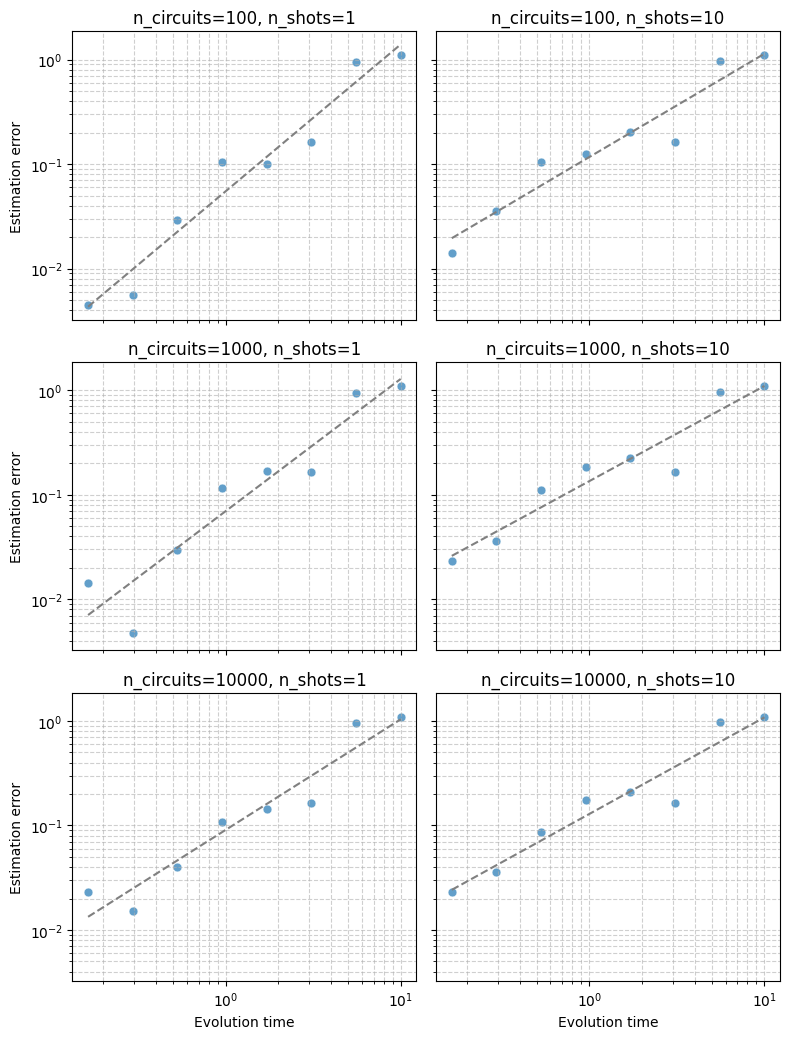

In [7]:

df["error_according_to_mean"] = abs(df["est_energy_mean"] - df["exact_eig"])
plot_qdrift_results(df)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

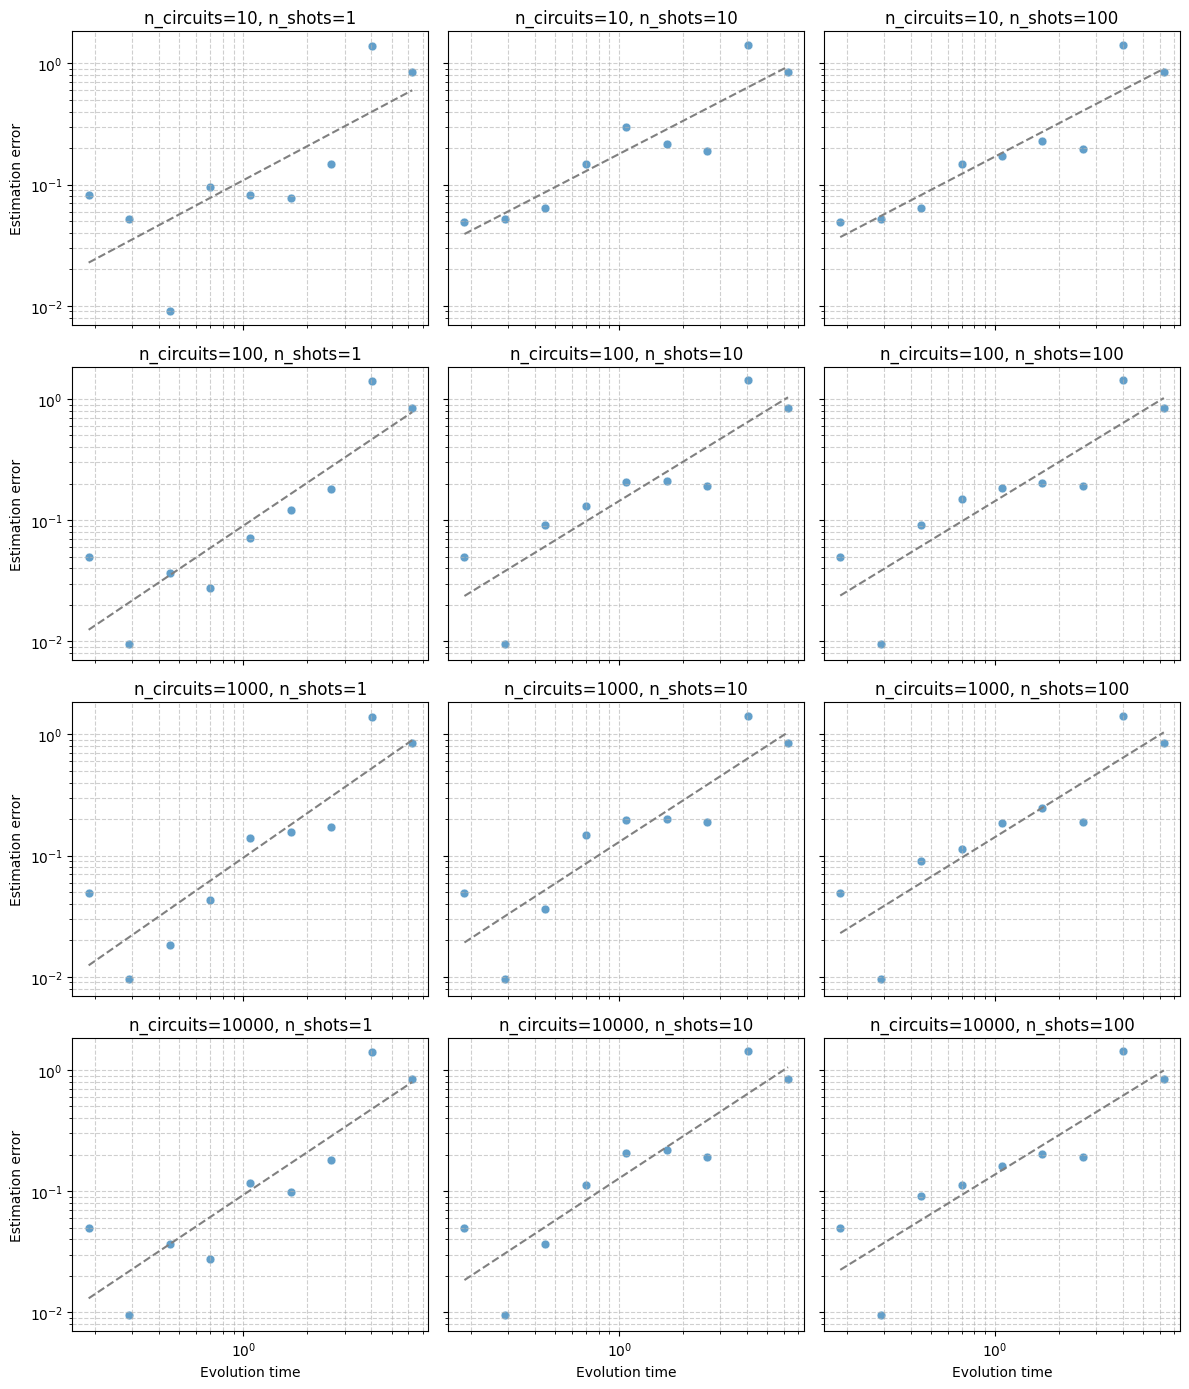

In [12]:
df2 = pd.read_csv(r"C:\Users\rodcs\Desktop\my-repos\qDriftExtraPolation\qdrift_qpe_fc_parameter_sweep_2025-09-23.csv")

times = sorted(df2["time"].unique())
df2 = df2[df2["time"] > times[0] ]  # filter for specific ancilla count if needed 
plot_qdrift_results(df2)